Mount Google Drive and Unzip the Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

!unzip /content/drive/MyDrive/'Forest Fire Dataset.zip' -d /content

!ls /content/'Forest Fire Dataset'

 9144b612-7ca6-4cfa-aa5a-1f721e85710e.pdf
'ARYA KHOSRAVIRD.pdf'
'carta di identita.pdf'
'Colab Notebooks'
'Copy of تکلیف شماره یک آریا خسروی راد.gdoc'
'Forest Fire Dataset.zip'
'letter of recommendation.pdf'
'resilient main'
 Self_Declaration_English_Arya_Khosravirad.pdf
 TrustWalletBackup
 wellness.drawio
Archive:  /content/drive/MyDrive/Forest Fire Dataset.zip
   creating: /content/Forest Fire Dataset/
   creating: /content/Forest Fire Dataset/Forest Fire Dataset/
   creating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0002.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0015.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0027.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0038.jpg  
  inflating: /content/Forest Fire Dataset/Forest Fire Dataset/Testing/fire_0040.jpg  
  inflating: /content/Fores

In [ ]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, GlobalAveragePooling2D, BatchNormalization, Activation
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import roc_auc_score, average_precision_score
from tensorflow.keras.regularizers import l2
import random
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.optimizers import Adam
import re
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, auc

Step 1: Data Collection and Preprocessing


In [ ]:
train_fire_path = '/content/Forest Fire Dataset/Training/fire'
train_nofire_path = '/content/Forest Fire Dataset/Training/nofire'
test_path = '/content/Forest Fire Dataset/Testing'

In [ ]:
def is_bad_image(img_rgb, file=None, min_unique=50, mean_lo=5, mean_hi=250, blur_thr=20.0):

    if img_rgb is None:
        print(f"[Skipped unreadable] {file}" if file else "[Skipped unreadable]")
        return True

    # grayscale version
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) if img_rgb.ndim == 3 else img_rgb

    # 1) Near-blank check
    if np.unique(gray).size < min_unique:
        print(f"[Skipped near-blank] {file}" if file else "[Skipped near-blank]")
        return True

    m = float(gray.mean())
    if m < mean_lo or m > mean_hi:
        print(f"[Skipped extreme brightness] {file} (mean={m:.1f})" if file else f"[Skipped extreme brightness] (mean={m:.1f})")
        return True

    # 2) Blur check
    lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
    if lap_var < blur_thr:
        print(f"[Skipped blurry] {file} (var={lap_var:.1f})" if file else f"[Skipped blurry] (var={lap_var:.1f})")
        return True

    return False

In [ ]:
def list_file_types_in_directory(directory):
    file_types = set([file.split('.')[-1] for file in os.listdir(directory)
                      if os.path.isfile(os.path.join(directory, file))])
    return file_types

train_fire_file_types = list_file_types_in_directory(train_fire_path)
train_nofire_file_types = list_file_types_in_directory(train_nofire_path)
test_file_types = list_file_types_in_directory(test_path)

print("File types in Train Fire:", train_fire_file_types)
print("File types in Train No Fire:", train_nofire_file_types)
print("File types in Test:", test_file_types)

File types in Train Fire: {'jpg'}
File types in Train No Fire: {'jpg'}
File types in Test: {'jpg'}


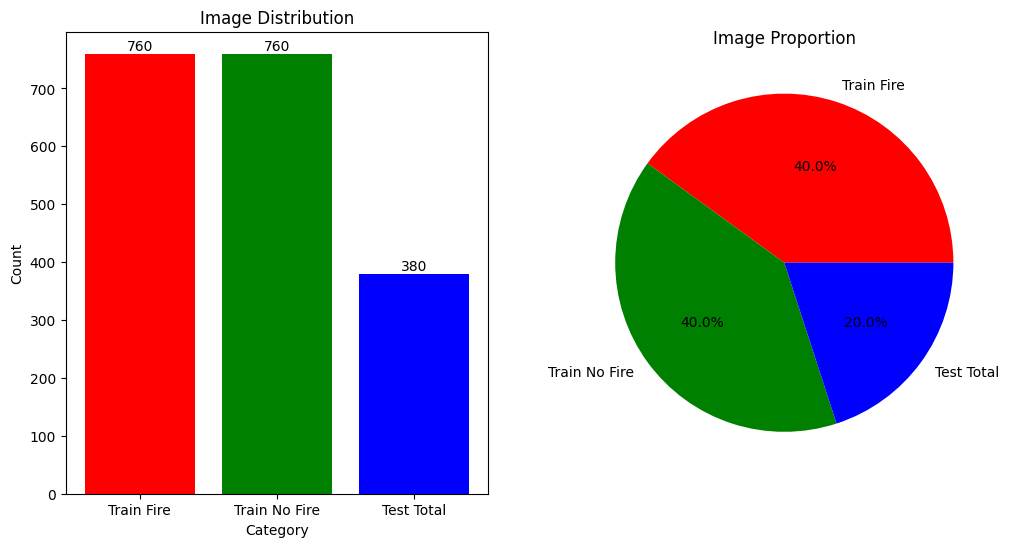

In [ ]:
def count_images_in_directory(directory):
    return len([file for file in os.listdir(directory) if file.endswith('.jpg')])

train_fire_count = count_images_in_directory(train_fire_path)
train_nofire_count = count_images_in_directory(train_nofire_path)
test_total_count = count_images_in_directory(test_path)

labels = ['Train Fire', 'Train No Fire', 'Test Total']
counts = [train_fire_count, train_nofire_count, test_total_count]

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
bars = plt.bar(labels, counts, color=['red', 'green', 'blue'])
plt.title('Image Distribution')
plt.xlabel('Category')
plt.ylabel('Count')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height}', ha='center', va='bottom')

plt.subplot(1, 2, 2)
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['red', 'green', 'blue'])
plt.title('Image Proportion')

plt.show()


In [ ]:
def load_images_from_directory(directory, label=None, return_names=False, extensions=('.jpg')):

    images = []
    labels = []
    filenames = []

    for file in sorted(os.listdir(directory)):
        if not file.lower().endswith(extensions):
            continue

        path = os.path.join(directory, file)
        img = cv2.imread(path)

        if img is None:
            is_bad_image(None, file=path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)

        if is_bad_image(img, file=path):
            continue

        images.append(img)
        if label is not None:
            labels.append(label)
        filenames.append(file)

    images = np.array(images, dtype='float32')
    labels = np.array(labels, dtype='int32') if label is not None else np.array([], dtype='int32')
    filenames = np.array(filenames, dtype=object)

    if return_names:
        return images, labels, filenames
    return images, labels

In [ ]:
train_fire_images, train_fire_labels = load_images_from_directory(train_fire_path, 1)
train_nofire_images, train_nofire_labels = load_images_from_directory(train_nofire_path, 0)

[Skipped blurry] /content/Forest Fire Dataset/Training/fire/fire_0047.jpg (var=16.8)
[Skipped blurry] /content/Forest Fire Dataset/Training/fire/fire_0168.jpg (var=11.2)
[Skipped blurry] /content/Forest Fire Dataset/Training/fire/fire_0934.jpg (var=10.8)
[Skipped blurry] /content/Forest Fire Dataset/Training/nofire/nofire_0419.jpg (var=7.8)
[Skipped blurry] /content/Forest Fire Dataset/Training/nofire/nofire_0421.jpg (var=15.8)


In [ ]:
print(train_fire_images.shape,
train_fire_labels.shape,
train_nofire_images.shape,
train_fire_labels.shape)

(757, 224, 224, 3) (757,) (758, 224, 224, 3) (757,)


In [ ]:
X_train = np.concatenate((train_fire_images, train_nofire_images), axis=0)
y_train = np.concatenate((train_fire_labels, train_nofire_labels), axis=0)

In [ ]:
print(X_train.shape, y_train.shape)

(1515, 224, 224, 3) (1515,)


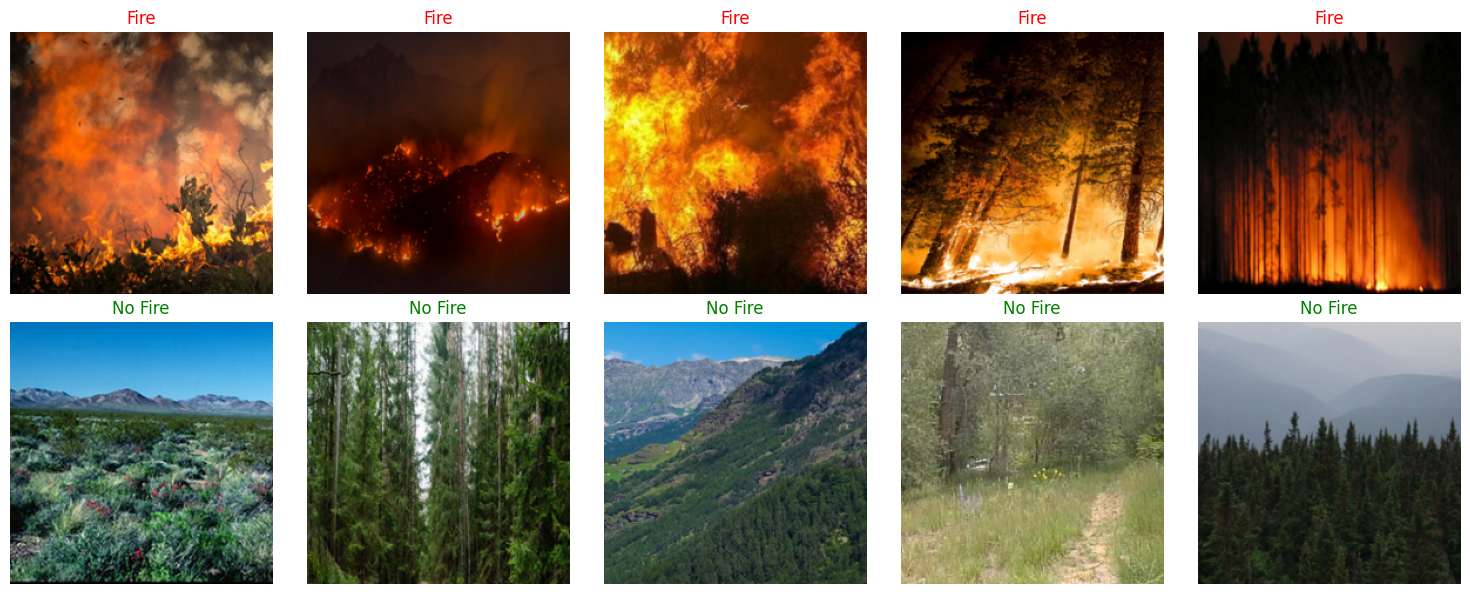

In [ ]:
fire_indices = random.sample(range(len(train_fire_images)), 5)
nofire_indices = random.sample(range(len(train_nofire_images)), 5)

plt.figure(figsize=(15, 6))

for i, idx in enumerate(fire_indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(train_fire_images[idx].astype('uint8'))
    plt.title("Fire", color="red")
    plt.axis("off")

for i, idx in enumerate(nofire_indices):
    plt.subplot(2, 5, i+6)
    plt.imshow(train_nofire_images[idx].astype('uint8'))
    plt.title("No Fire", color="green")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
test_images, _, test_image_names = load_images_from_directory(test_path, None, return_names=True)

[Skipped blurry] /content/Forest Fire Dataset/Testing/nofire_0574.jpg (var=18.3)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
print(f'Training data shape: {X_train.shape}')
print(f'Validation data shape: {X_val.shape}')
print(f'Testing data shape: {test_images.shape}')

Training data shape: (1212, 224, 224, 3)
Validation data shape: (303, 224, 224, 3)
Testing data shape: (379, 224, 224, 3)


Step 2: Building and Training the Fire Detection Model



In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_flow = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True, seed=42)
val_flow   = val_datagen.flow(X_val,   y_val,   batch_size=32, shuffle=False)

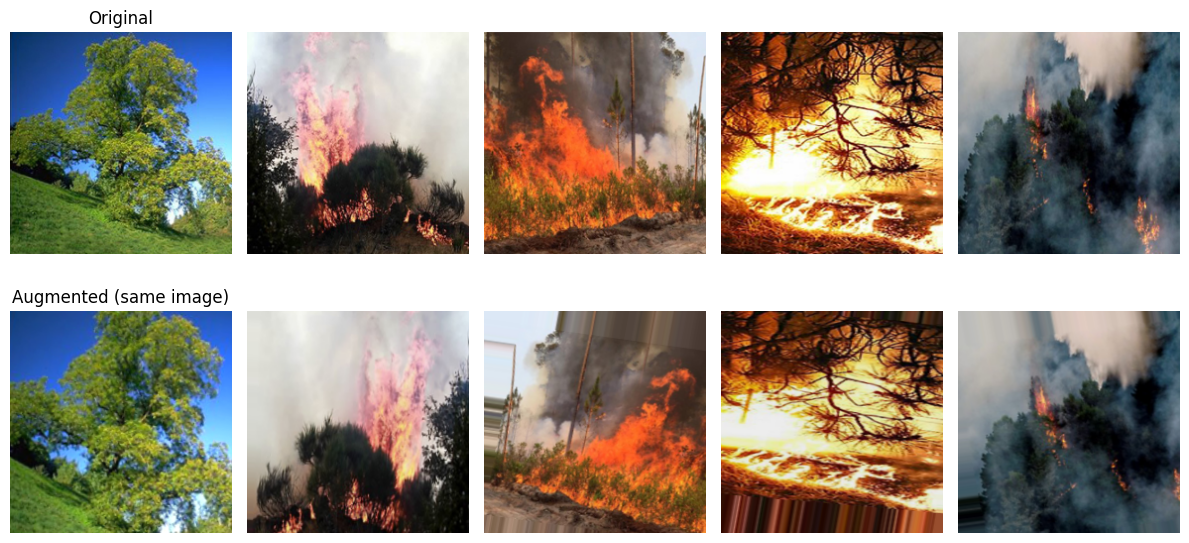

In [ ]:
num_samples = 5
fig, axes = plt.subplots(2, num_samples, figsize=(12, 6))

for i in range(num_samples):
    img = X_train[i]

    axes[0, i].imshow(np.clip(img, 0, 255).astype(np.uint8))
    axes[0, i].axis('off')

    aug_img = train_flow.image_data_generator.random_transform(img)
    axes[1, i].imshow(np.clip(aug_img, 0, 255).astype(np.uint8))
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Augmented (same image)")
plt.tight_layout()
plt.show()

In [ ]:
backbone = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3), pooling="avg")
backbone.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
x = backbone.output
x = Dense(64, use_bias=False,
          kernel_initializer="he_normal",
          kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
x = BatchNormalization()(x)
x = Activation("relu")(x)
x = Dropout(0.5)(x)
out = Dense(1, activation="sigmoid")(x)

In [ ]:
model = Model(backbone.input, out)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics = ["accuracy"])

In [ ]:
callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_loss", mode="min",patience=2, restore_best_weights=True)]

history = model.fit(
    train_flow,
    validation_data=val_flow,
    epochs=12,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 47s 848ms/step - accuracy: 0.5606 - loss: 2.0287 - val_accuracy: 0.6403 - val_loss: 1.8856
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 467ms/step - accuracy: 0.5979 - loss: 1.9832 - val_accuracy: 0.7294 - val_loss: 1.8109
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 539ms/step - accuracy: 0.6844 - loss: 1.8684 - val_accuracy: 0.7756 - val_loss: 1.7452
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 485ms/step - accuracy: 0.7255 - loss: 1.8175 - val_accuracy: 0.8119 - val_loss: 1.6873
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 476ms/step - accuracy: 0.7815 - loss: 1.7406 - val_accuracy: 0.8350 - val_loss: 1.6335
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 471ms/step - accuracy: 0.8286 - loss: 1.6689 - val_accuracy: 0.8779 - val_loss: 1.5865
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 477ms/step - accuracy: 0.8436 - loss: 1.6159 - val_accuracy: 0.9076 - val_loss: 1.5460
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 470ms/step - accuracy: 0.8673 - loss: 1.5791 - val_accu

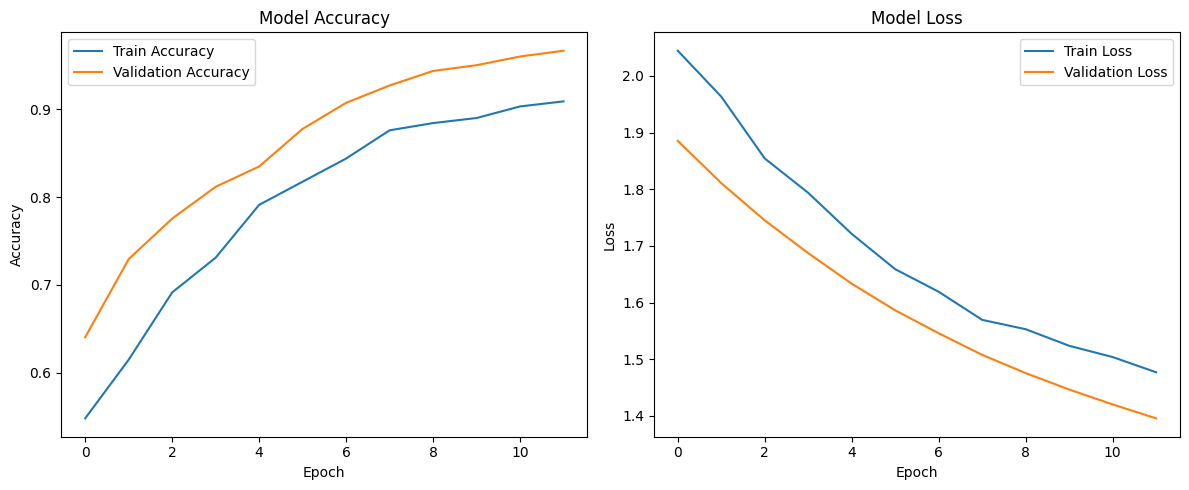

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Step **4**: Evaluate Model Performance

In [ ]:
keep_mask = np.array([n.lower().startswith(("fire_", "nofire_")) for n in test_image_names])

names_eval = np.array(test_image_names)[keep_mask]
test_images_eval = test_images[keep_mask]

y_test_eval = np.array([1 if n.lower().startswith("fire_") else 0 for n in names_eval], dtype=int)

print(f"Test samples used for eval: {len(y_test_eval)} (fire={y_test_eval.sum()}, nofire={(y_test_eval==0).sum()})")

Test samples used for eval: 379 (fire=190, nofire=189)


In [ ]:
test_probs = model.predict(preprocess_input(test_images_eval), verbose=0).ravel()

In [ ]:
test_pred  = (test_probs >= 0.5).astype(int)

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test_eval, test_pred, target_names=["No Fire", "Fire"], digits=4))


Classification Report:
              precision    recall  f1-score   support

     No Fire     0.9834    0.9418    0.9622       189
        Fire     0.9444    0.9842    0.9639       190

    accuracy                         0.9631       379
   macro avg     0.9639    0.9630    0.9630       379
weighted avg     0.9639    0.9631    0.9630       379



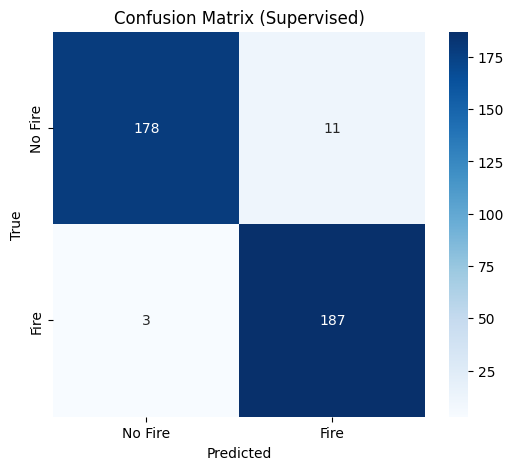

In [ ]:
cm = confusion_matrix(y_test_eval, test_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Supervised)")
plt.show()

In [ ]:
score_va = model.predict(preprocess_input(X_val.copy()),   verbose=0).ravel()

BETA = 2.5
P_val, R_val, T_val = precision_recall_curve(y_val.astype(int), score_va)
Pv, Rv = P_val[:-1], R_val[:-1]

fbeta = (1 + BETA**2) * P_val * R_val / (BETA**2 * P_val + R_val + 1e-12)
j = int(np.argmax(fbeta))
THRESH = float(T_val[j])

print(f"Chosen THRESH (val, F{BETA}-max) = {THRESH}")

Chosen THRESH (val, F2.5-max) = 0.5142160654067993


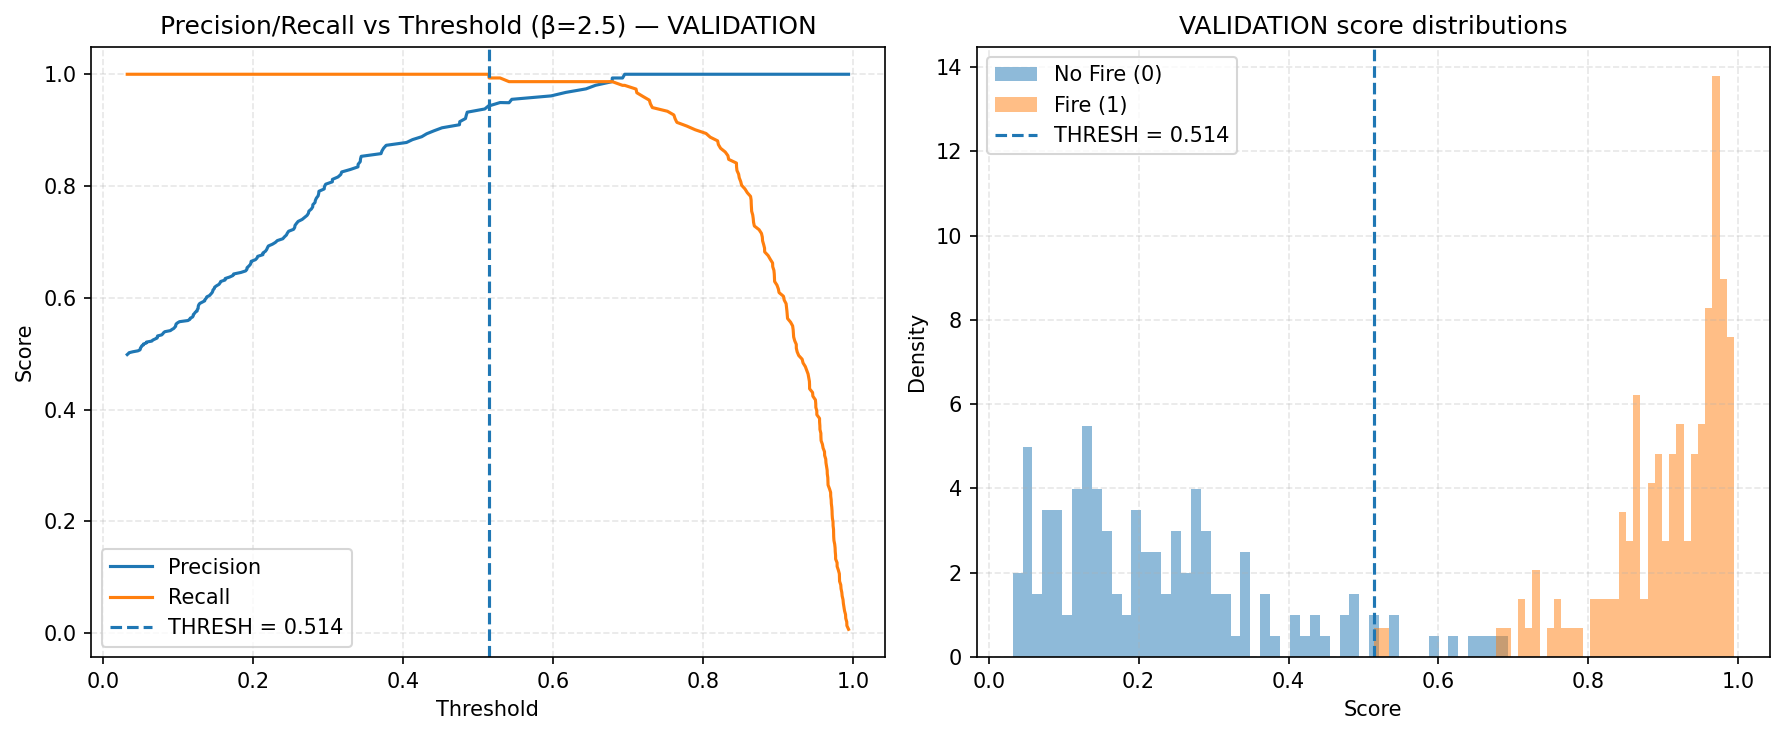

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

axes[0].plot(T_val, Pv, label="Precision")
axes[0].plot(T_val, Rv, label="Recall")
axes[0].axvline(THRESH, linestyle="--", label=f"THRESH = {THRESH:.3f}")
axes[0].set_xlabel("Threshold"); axes[0].set_ylabel("Score")
axes[0].set_title(f"Precision/Recall vs Threshold (β={BETA}) — VALIDATION")
axes[0].legend(); axes[0].grid(True, ls="--", alpha=0.3)

axes[1].hist(score_va[y_val==0], bins=50, alpha=0.5, density=True, label="No Fire (0)")
axes[1].hist(score_va[y_val==1], bins=50, alpha=0.5, density=True, label="Fire (1)")
axes[1].axvline(THRESH, linestyle="--", label=f"THRESH = {THRESH:.3f}")
axes[1].set_xlabel("Score"); axes[1].set_ylabel("Density")
axes[1].set_title("VALIDATION score distributions")
axes[1].legend(); axes[1].grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
test_pred_tuned  = (test_probs >=  THRESH).astype(int)

In [ ]:
test_pred_tuned  = (test_probs >=  THRESH).astype(int)
print("\nClassification Report:")
print(classification_report(y_test_eval, test_pred_tuned, target_names=["No Fire", "Fire"], digits=4))


Classification Report:
              precision    recall  f1-score   support

     No Fire     0.9835    0.9471    0.9650       189
        Fire     0.9492    0.9842    0.9664       190

    accuracy                         0.9657       379
   macro avg     0.9664    0.9657    0.9657       379
weighted avg     0.9663    0.9657    0.9657       379



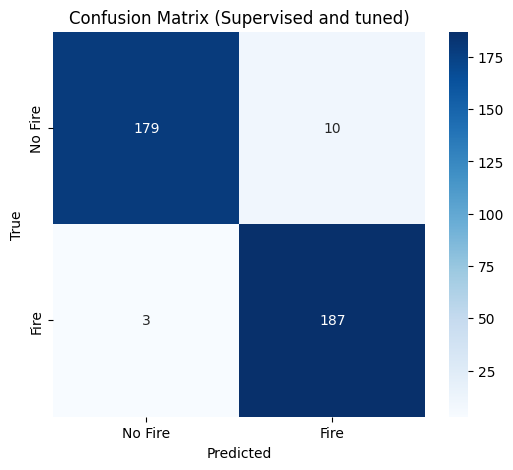

In [ ]:
cm = confusion_matrix(y_test_eval, test_pred_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Fire", "Fire"], yticklabels=["No Fire", "Fire"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Supervised and tuned)")
plt.show()

In [ ]:
def supervised_simulation(test_image_names, test_probs, shuffle=True):
    thr = THRESH
    probs = np.ravel(test_probs).astype(float)
    results = [(n, float(p), ('DROP' if p >= thr else 'EXIT'))
               for n, p in zip(test_image_names, probs)]
    if shuffle:
        np.random.default_rng().shuffle(results)
    shown = results[:8]
    for i, (name, p, decision) in enumerate(shown, start=1):
        print(f"Location {i} — {decision.lower()} (risk={p:.4f})")

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for ax in axes: ax.axis("off")

    for idx, (name, p, decision) in enumerate(shown):
        path = name if os.path.exists(name) else os.path.join(test_path, name) if 'test_path' in globals() else name
        img = cv2.imread(path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[idx].imshow(img)
            axes[idx].set_title(f"{os.path.basename(str(name))}\n{decision.lower()} (p={p:.3f})", fontsize=9)
        else:
            axes[idx].text(0.5, 0.5, f"Missing:\n{name}", ha="center", va="center")
            axes[idx].set_title(f"{os.path.basename(str(name))}", fontsize=9)

    plt.tight_layout()
    plt.show()
    return results, shown

Location 1 — exit (risk=0.0878)
Location 2 — drop (risk=0.9303)
Location 3 — exit (risk=0.1805)
Location 4 — drop (risk=0.8350)
Location 5 — exit (risk=0.4189)
Location 6 — exit (risk=0.1603)
Location 7 — exit (risk=0.0471)
Location 8 — drop (risk=0.8474)


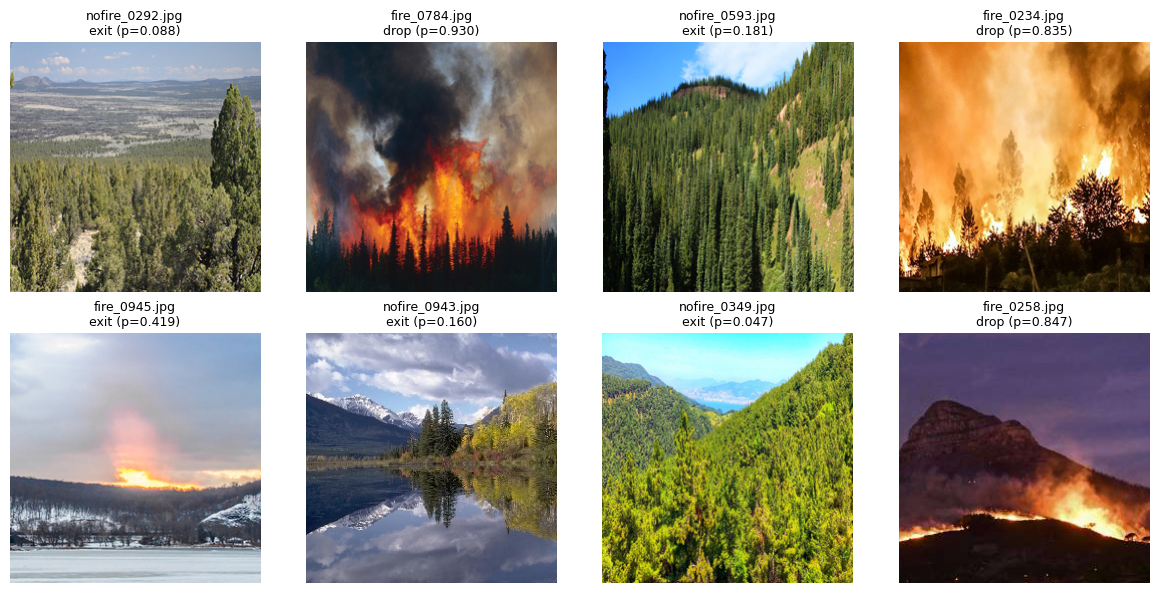

In [ ]:
results, shown = supervised_simulation(test_image_names, test_probs, shuffle = True)

Step 5:Drone Deployment and Fire Suppression
